# Stats and visuals for the public spine

In [4]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot
import upsetplot


There are 777377 rows in the main spine, 1294887 rows of supplementary data and 104808 matches found.

In [5]:
basefilename = '/Users/fionack/Projects/TSO_project/public_spine_data/public_spine'
#basefilename = '/Users/fionack/Projects/TSO_project/tso-database-builder/main_spine.ccew.oscr.ccni.ch.csv'#main_spine.ccew.oscr'
spine_df = pd.read_csv(basefilename+'.spine.csv',usecols=['uid','normalisedname'])
extras_df = pd.read_csv(basefilename+'.supplementary.csv',usecols=['uid','normalisedname','source'])
matches_df = pd.read_csv(basefilename+'.matches.csv')

print(f'There are {spine_df.shape[0]} rows in the main spine, {extras_df.shape[0]} rows of supplementary data and {matches_df.shape[0]} matches found.\n')

There are 777377 rows in the main spine, 1294887 rows of supplementary data and 104831 matches found.



/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_64447/980172203.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  matches_df = pd.read_csv(basefilename+'.matches.csv')


## Counts per source in main spine

basesource
COH     354443
CHC     337826
SC       49306
MPR      18649
COOP      9239
NIC       7746
SHR        158
SHPE        10
Name: count, dtype: int64


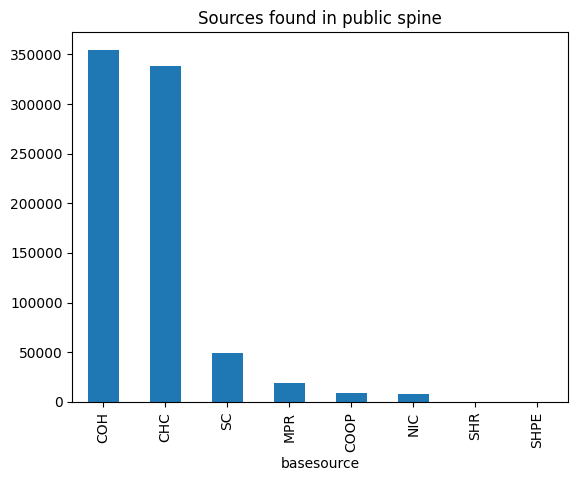

In [6]:
spine_df['basesource'] = spine_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = spine_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
print(source_counts)
source_counts.plot(kind='bar')
pyplot.title('Sources found in public spine')
pyplot.savefig('%s.sources.png'%basefilename)


Text(0.5, 1.0, 'Sources found in supplementary data')

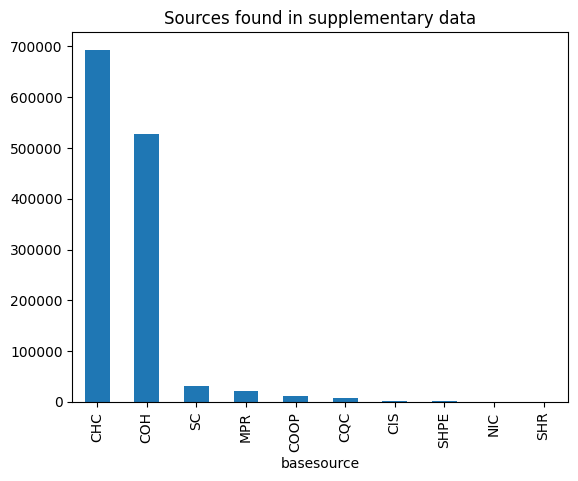

In [7]:
extras_df['basesource'] = extras_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = extras_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
source_counts.plot(kind='bar')
pyplot.title('Sources found in supplementary data')


                    uid
0       GB-COH-06812512
1       GB-COH-05140020
2       GB-COH-15098833
3       GB-COH-14259870
4       GB-COH-12578249
...                 ...
873059   GB-CHC-1202141
873060    GB-MPR-28838R
873061   GB-SC-SC015236
873062   GB-SC-SC051121
873063  GB-COH-03770064

[873064 rows x 1 columns]
basesource
COH     428276
CHC     341870
SC       50566
MPR      31673
COOP     10562
NIC       7746
CQC        970
SHPE       712
CIS        531
SHR        158
Name: count, dtype: int64


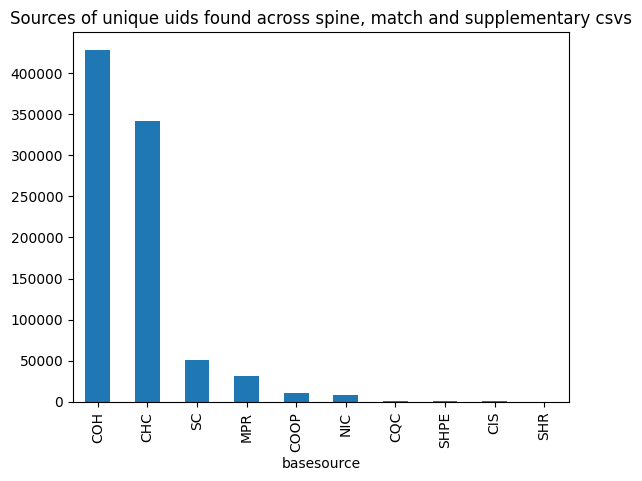

In [8]:
# find all uids used across all data:
uid_set = set(list(spine_df['uid']) + list(matches_df['orgA_uid']) + list(matches_df['orgB_uid']) + list(extras_df['uid']))

all_df = pd.DataFrame(uid_set,columns=['uid'])
print(all_df)
all_df['basesource'] = all_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = all_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
print(source_counts)
source_counts.plot(kind='bar')


pyplot.title('Sources of unique uids found across spine, match and supplementary csvs')

pyplot.savefig('%s.all.sources.png'%basefilename)


source_counts = [f"{source} & {count} \\\\ \\hline\n" for source, count in source_counts.items()]

with open(basefilename+'.all_used_orgs.tab.tex', 'w') as ofile:

    ofile.write('\\begin{table}[h]\n  \\centering\n')
    ofile.write('\\begin{tabular}{|l|r|}\n    \\hline\n')
    ofile.write('Source & Count of orgs \\\\ \\hline \\hline\n')

    for i in source_counts:
        ofile.write(i)

    ofile.write('\\end{tabular}\n')
    ofile.write('\\caption{Count of organisations per source}\n')
    ofile.write('\\label{tab:all_used_orgs}\n')
    ofile.write('\\end{table}\n')



                 match_type  count
0                       ftc  55982
1  companyid - id_in_source  35836
2   companyid - coop mutual   9933
3               name - care   1831
4            name - housing    678
5     companyid - companyid    337
6        name - crossborder    234


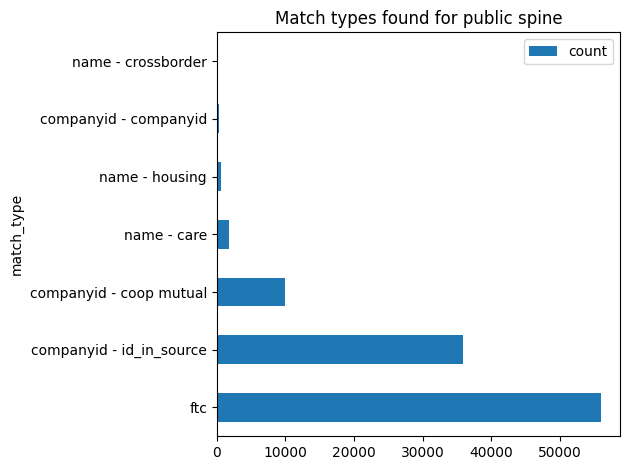

In [31]:

match_types = matches_df['match_type'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})
match_types = match_types.reset_index()
match_types.columns = ['match_type','count']

print(match_types)
match_types.plot(y='count', x='match_type', kind='barh')
pyplot.title('Match types found for public spine')
pyplot.tight_layout()
pyplot.savefig('%s.matchtypes.png'%basefilename)
pyplot.show()
# also think of how to plot this so that identical matches are shown in a different way - pairs of organisations which are matched by ftc and also name, for example - this chart doesn't differentiate



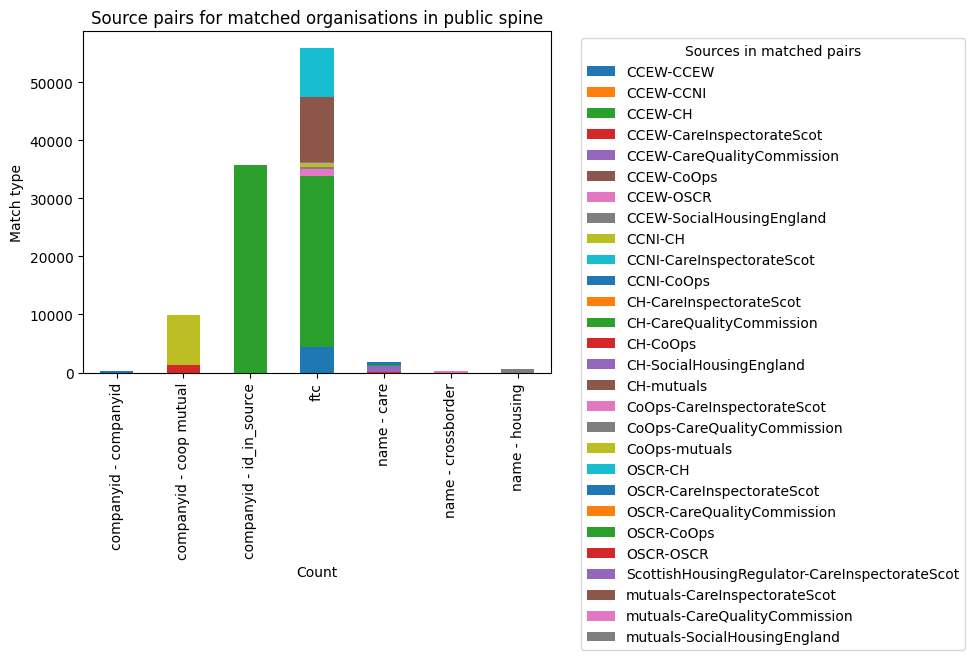

<Figure size 640x480 with 0 Axes>

In [29]:
matches_df['source-source'] = matches_df.apply(lambda row: '%s-%s'%(row['orgA_source'],row['orgB_source']), axis=1)
match_types = matches_df.groupby('match_type')['source-source'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})

# Convert Series to DataFrame for plotting
match_types = match_types.unstack().fillna(0)

# Plot the data
match_types.plot(kind='bar', stacked=True, figsize=(10, 6))
pyplot.title('Source pairs for matched organisations in public spine')
pyplot.legend(title='Sources in matched pairs', bbox_to_anchor=(1.05, 1), loc='upper left')
pyplot.xlabel('Count')
pyplot.ylabel('Match type')
pyplot.tight_layout()
pyplot.show()
pyplot.savefig('%s.match_source_pairs.types.png'%basefilename)

In [11]:
def plot_upset_matches(infile):
     #print(type(source_list))
    df = pd.read_csv(infile,usecols=['orgA_source','orgB_source'])
    source_order = {'CCEW': 1, 
                    'OSCR' : 2,
                    'CCNI': 3, 
                    'CH' : 4,
                    'CoOps' : 5,
                    'mutuals' : 6,
                    'ScottishHousingRegulator' : 7,
                    'SocialHousingEngland' : 8,
                    'CareInspectorateScot' : 9,
                    'CareQualityCommission' : 10
                    }

    for s in source_order.keys():
    
        df[s] = (matches_df['orgA_source'] == s) | (matches_df['orgB_source'] == s)
        # now df has a column for each source type, indicating whether uid is from source or not
    
    df.drop(labels=['orgA_source','orgB_source'],axis=1, inplace=True)
    source_list = df.columns.tolist()
    # Group by source_list and get the size
    df_grouped = df.groupby(source_list).size()
    
    upsetplot.plot(df_grouped, orientation='horizontal')#, sort_by=source_order)

    pyplot.title("Matches between data sources found in %s"%os.path.basename(infile))
    pyplot.savefig('%s.upsetplot.png'%infile)
    pyplot.show()


/Users/fionack/Projects/TSO_project/tso-database-builder/.tso/lib/python3.11/site-packages/upsetplot/plotting.py:662: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' 'black' 'black' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 'black' '#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' 'black' '#0000002e'
 '#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' 'black' '#0000002e' 'black'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 'black' '#0000002e' '#0000002e' '#0000002e' 'black' '#0000002e'
 '#000000

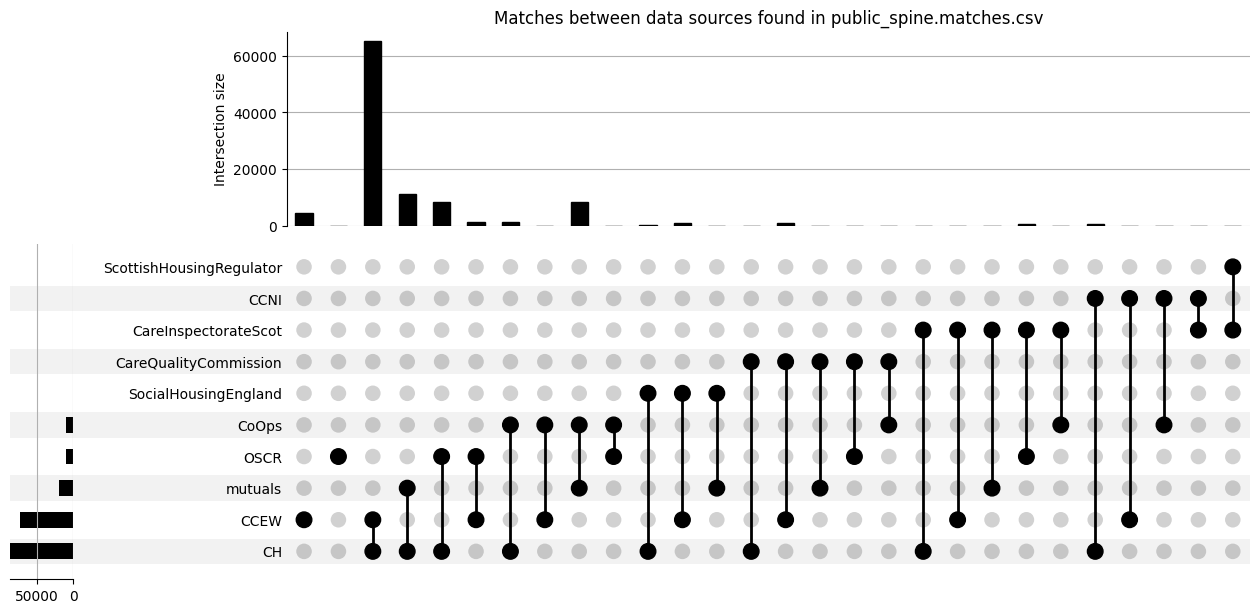

In [12]:
plot_upset_matches(basefilename+'.matches.csv')

In [13]:

sources = np.union1d(matches_df['orgB_source'].unique(), matches_df['orgA_source'].unique())

print(sources)

['CCEW' 'CCNI' 'CH' 'CareInspectorateScot' 'CareQualityCommission' 'CoOps'
 'OSCR' 'ScottishHousingRegulator' 'SocialHousingEngland' 'mutuals']


In [14]:
uids_in_matches_df = set(matches_df['orgA_uid'] + matches_df['orgB_uid'])
print(f'Unique uids in matches csv = {len(uids_in_matches_df)}')
print(f"Unique uids in main spine csv = {len(set(spine_df['uid']))}")

orga_uids = set(matches_df['orgA_uid'])
orgb_uids = set(matches_df['orgB_uid'])

print(f'Organisations found in positions OrgA and OrgB in matches.csv: {orga_uids.intersection(orgb_uids)}')
print(f'Number of unique organisations in position OrgA = {len(orga_uids)}, and unique OrgB uids = {len(orgb_uids)}')

Unique uids in matches csv = 104060
Unique uids in main spine csv = 777377
Organisations found in positions OrgA and OrgB in matches.csv: set()
Number of unique organisations in position OrgA = 99793, and unique OrgB uids = 95999


In [15]:
match_types

source-source,CCEW-CCEW,CCEW-CCNI,CCEW-CH,CCEW-CareInspectorateScot,CCEW-CareQualityCommission,CCEW-CoOps,CCEW-OSCR,CCEW-SocialHousingEngland,CCNI-CH,CCNI-CareInspectorateScot,...,CoOps-mutuals,OSCR-CH,OSCR-CareInspectorateScot,OSCR-CareQualityCommission,OSCR-CoOps,OSCR-OSCR,ScottishHousingRegulator-CareInspectorateScot,mutuals-CareInspectorateScot,mutuals-CareQualityCommission,mutuals-SocialHousingEngland
match_type,,,,,,,,,,,,,,,,,,,,,
companyid - companyid,292.0,1.0,0.0,0.0,0.0,42.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
companyid - coop mutual,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8609.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
companyid - id_in_source,0.0,0.0,35836.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ftc,4452.0,0.0,29341.0,0.0,0.0,0.0,1239.0,473.0,655.0,0.0,...,0.0,8497.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
name - care,0.0,0.0,0.0,22.0,1066.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,552.0,4.0,0.0,0.0,15.0,3.0,1.0,0.0
name - crossborder,0.0,0.0,0.0,0.0,0.0,0.0,233.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
name - housing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,569.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0


Find the numbers of matches found by any combination of match types:

In [16]:
match_types_dict = {}  #
uid_uid_match_dict = {}
#print(matches_df)                   
matches_df['uid-uid'] = matches_df.apply(lambda row: '%s:%s' % tuple(sorted([row['orgA_uid'], row['orgB_uid']])), axis=1)
#print(matches_df)
#
unique_uidA_uidB = set(matches_df['uid-uid'])
#print(unique_uidA_uidB)
print(f'Number of uniquely matched pairs of orgs in matches csv = {len(unique_uidA_uidB)} (of {matches_df.shape[0]} rows in matches csv)')
print(f' ==> number of org pairs found in multiple ways = {matches_df.shape[0]-len(unique_uidA_uidB)}')
matches_df['uid-uid'].value_counts()



Number of uniquely matched pairs of orgs in matches csv = 104060 (of 104831 rows in matches csv)
 ==> number of org pairs found in multiple ways = 771


uid-uid
GB-CHC-220235:GB-SC-SC045876      2
GB-CHC-1077216:GB-SC-SC045059     2
GB-CHC-1074516:GB-SHPE-LH4208     2
GB-CHC-1005857:GB-SHPE-A2266      2
GB-CHC-1157154:GB-SC-SC045076     2
                                 ..
GB-CHC-1148590:GB-COH-08141403    1
GB-CHC-1148588:GB-COH-07847447    1
GB-CHC-1148582:GB-COH-07578438    1
GB-CHC-1148581:GB-COH-06488936    1
GB-CIS-CS2003010646:GB-SHR-199    1
Name: count, Length: 104060, dtype: int64

Text(0, 0.5, 'Count of org pairs matched')

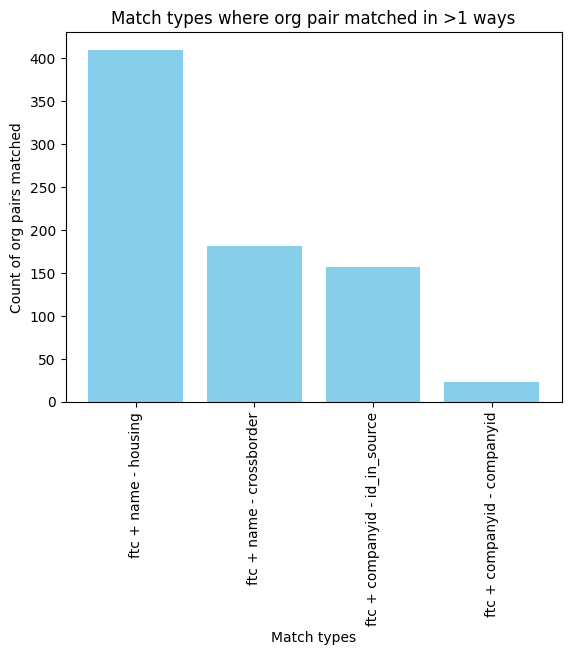

In [17]:

# plot the orgs matched in multiple ways:

def concat_strings(series):
    return ' + '.join(series)


concatenated = matches_df.groupby('uid-uid')['match_type'].apply(concat_strings).reset_index()
concatenated.columns = ['uid-uid','match_type']


counts = matches_df['uid-uid'].value_counts().reset_index()
counts.columns = ['uid-uid', 'count']


result = pd.merge(concatenated, counts, on='uid-uid')

two_matches= result[result['count']>1]
match_type_counts = two_matches['match_type'].value_counts().reset_index()
match_type_counts.columns = ['match_type', 'count']
pyplot.bar(match_type_counts['match_type'], match_type_counts['count'], color='skyblue')
pyplot.xticks(rotation=90)
pyplot.title('Match types where org pair matched in >1 ways')
pyplot.xlabel('Match types')
pyplot.ylabel('Count of org pairs matched')

#pyplot.bar(two_matches['match_type'],height=two_matches.groupby['match_type'].value_counts())



In [18]:

oscr_oscr_matches = matches_df[(matches_df['orgA_source'] == 'OSCR') & (matches_df['orgB_source'] == 'OSCR')]


In [19]:
oscr_oscr_matches

,uid,orgA_id_in_source,orgA_source,orgA_uid,orgB_id_in_source,orgB_source,orgB_uid,match_type,source-source,uid-uid
81173,GB-SC-SC050464,SC050464,OSCR,GB-SC-SC050464,SC051056,OSCR,GB-SC-SC051056,name - crossborder,OSCR-OSCR,GB-SC-SC050464:GB-SC-SC051056


In [ ]:

reports = [
('CCEW', {'CCEW': 337559}, {'CCEW': 5191}, 341990),
('OSCR', {'CCEW': 337559, 'OSCR': 49306}, {'CCEW': 5191, 'OSCR': 1569}, 392642),
('CCNI', {'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745}, {'CCEW': 5191, 'OSCR': 1569, 'CCNI': 1}, 400388),
('CH', {'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745, 'CH': 354443}, {'CCEW': 5191, 'CH': 74965, 'OSCR': 1569, 'CCNI': 1}, 829061),
('CoOps', {'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745, 'CH': 354443, 'CoOps': 9195}, {'CCEW': 5191, 'CH': 74965, 'OSCR': 1569, 'CCNI': 1, 'CoOps': 1368}, 839623),
('mutuals', {'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745, 'CH': 354443, 'CoOps': 9195, 'mutuals': 18649}, {'CCEW': 5191, 'CH': 74965, 'OSCR': 1569, 'CCNI': 1, 'CoOps': 1368, 'mutuals': 20102}, 871296),
('ScottishHousingRegulator', {'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745, 'CH': 354443, 'CoOps': 9195, 'mutuals': 18649, 'ScottishHousingRegulator': 158}, {'CCEW': 5191, 'CH': 74965, 'OSCR': 1569, 'CCNI': 1, 'CoOps': 1368, 'mutuals': 20102}, 871454),
('SocialHousingEngland', {'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745, 'CH': 354443, 'CoOps': 9195, 'mutuals': 18649, 'ScottishHousingRegulator': 158, 'SocialHousingEngland': 10}, {'CCEW': 5191, 'CH': 74965, 'SocialHousingEngland': 1979, 'OSCR': 1569, 'CCNI': 1, 'CoOps': 1368, 'mutuals': 20102}, 872774),
('CareInspectorateScot', {'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745, 'CH': 354443, 'CoOps': 9195, 'mutuals': 18649, 'ScottishHousingRegulator': 158, 'SocialHousingEngland': 10, 'CareInspectorateScot': 1582}, {'CCEW': 5191, 'CH': 74965, 'SocialHousingEngland': 1979, 'OSCR': 1569, 'CCNI': 1, 'CareInspectorateScot': 2689, 'CoOps': 1368, 'mutuals': 20102}, 876238),
('CareQualityCommission', {'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745, 'CH': 354443, 'CoOps': 9195, 'mutuals': 18649, 'ScottishHousingRegulator': 158, 'SocialHousingEngland': 10, 'CareInspectorateScot': 1582, 'CareQualityCommission': 35654}, {'CCEW': 5191, 'CH': 74965, 'SocialHousingEngland': 1979, 'CareQualityCommission': 1377, 'OSCR': 1569, 'CCNI': 1, 'CareInspectorateScot': 2689, 'CoOps': 1368, 'mutuals': 20102}, 912867),
]

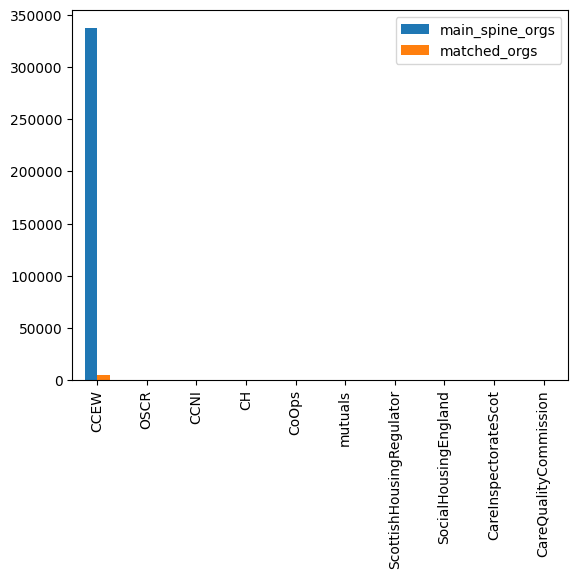

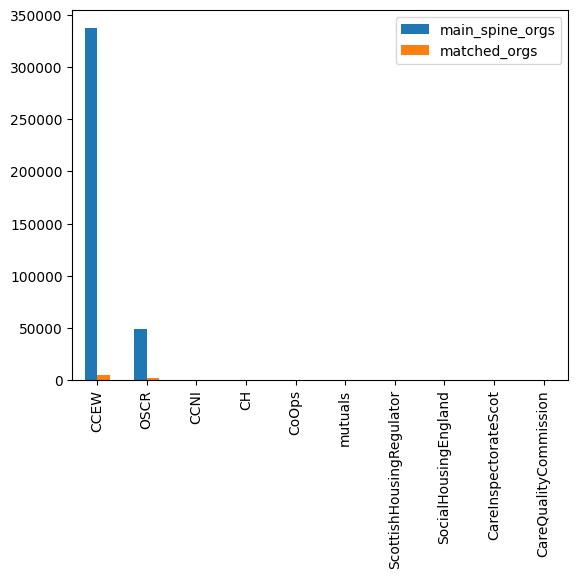

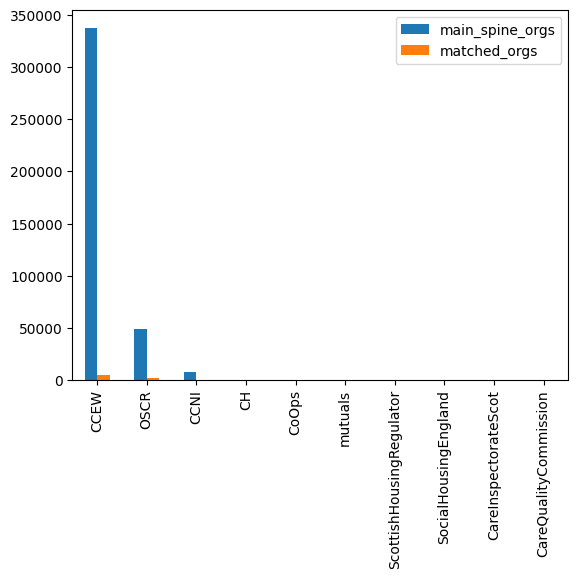

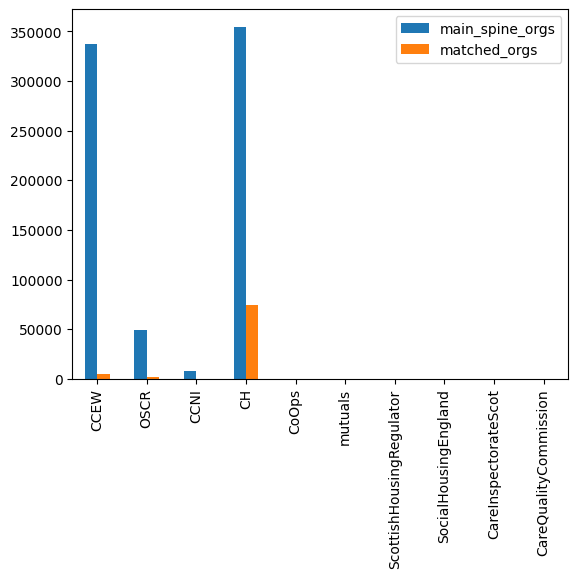

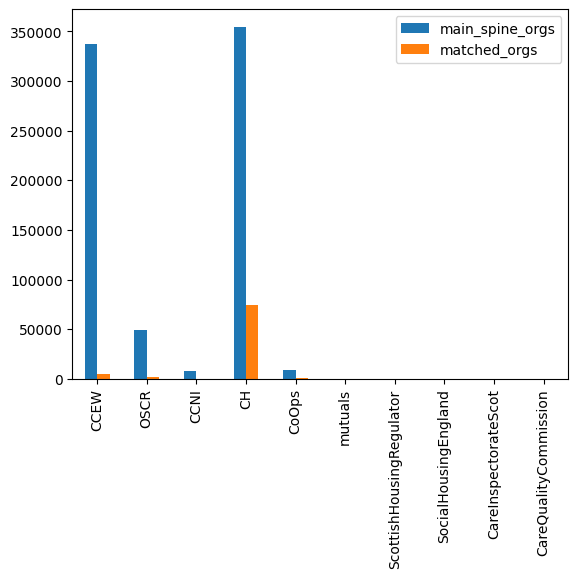

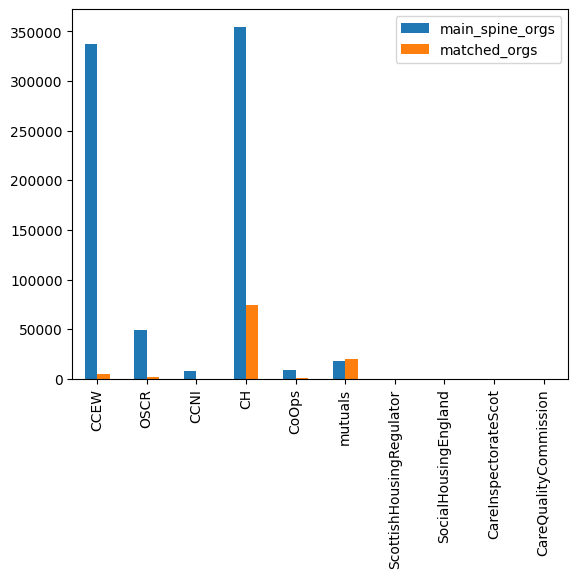

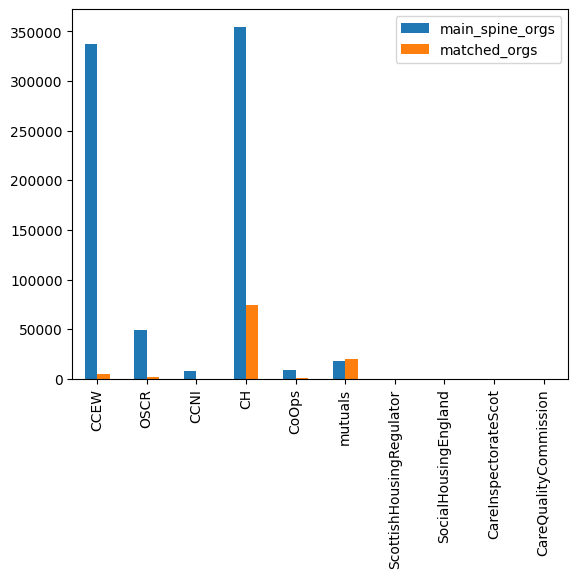

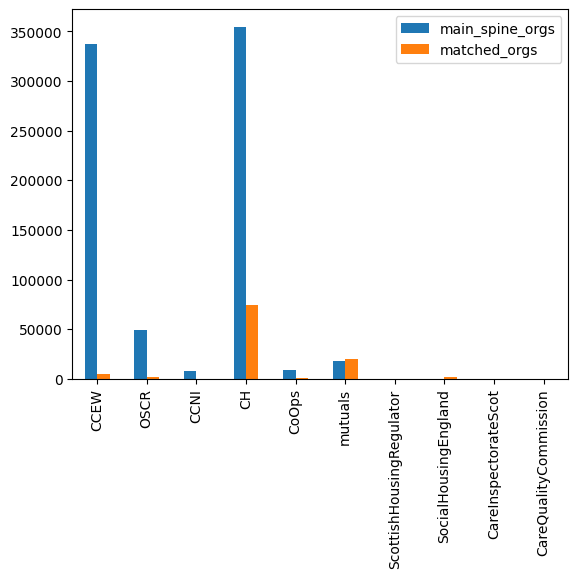

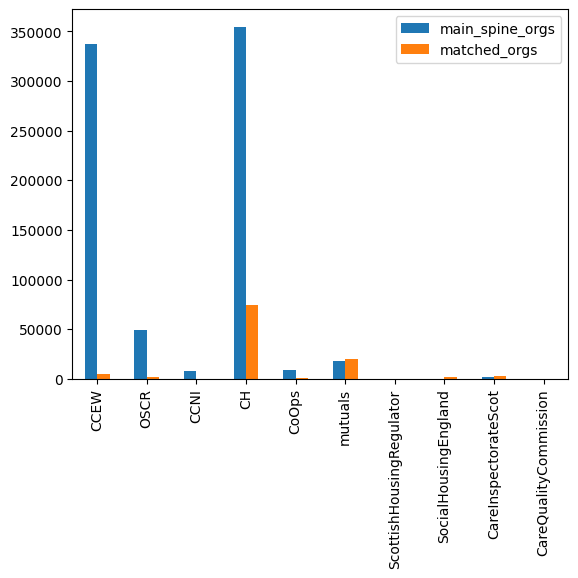

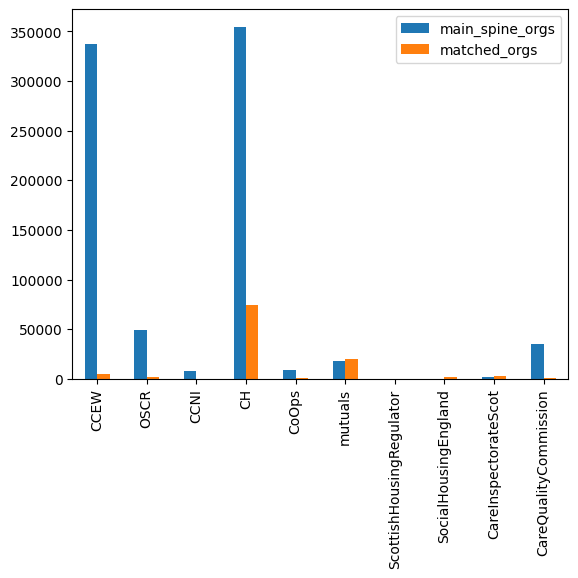

In [ ]:
sources = ['CCEW',
        'OSCR',
        'CCNI',
        'CH',
        'CoOps',
        'mutuals',
        'ScottishHousingRegulator',
        'SocialHousingEngland',
        'CareInspectorateScot',
        'CareQualityCommission']

for iteration in range(len(reports)):

    main=reports[iteration][1]
    matches=reports[iteration][2]
    
    for s in sources:
        if not s in matches:
            matches[s]=0
        if not s in main:
            main[s] = 0
            
    main_spine_orgs = [main[source] for source in sources]
    matched_orgs = [matches[source] for source in sources]
    df = pd.DataFrame({'main_spine_orgs': main_spine_orgs,
                       'matched_orgs': matched_orgs,
                       }, index=sources)
    ax = df.plot.bar(rot=90)

    pyplot.show()